# KV cache 太大了，于是有了 GQA

到目前为止（01、02 章），我们默认每个 query 头都配一个自己的 K/V 头——标准的多头注意力（MHA）。
训练时这没问题。可一旦进入**推理**，一个幽灵冒了出来：**KV cache**。

为了不重复计算，推理时要把历史所有 token 的 K/V 缓存在显存里。这块缓存会大到什么程度？
大到能轻松吃光一张显卡。这一章我们就从"KV cache 为什么这么大"出发，看 GQA / MQA 是怎么把它
成倍砍下来的——而秘诀，只是 kernel 里的**一句 head 映射**。

本章的 kernel 不是自己写的，而是从 vLLM 里**提取**出来的（生产框架的原生 GQA 实现）。


In [1]:
import sys, math
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "03-gqa-mqa"))

from common import naive_attention, make_qkv, bench_ms
from gqa import gqa_attention, gqa_attention_varlen

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0), "| 本章 kernel 提取自 vLLM 的 prefill attention")


跑在 NVIDIA GeForce RTX 4090 | 本章 kernel 提取自 vLLM 的 prefill attention


## 先被吓一跳：KV cache 到底有多大

拿一个 7B 级别模型的常见配置算一笔账：32 层、每层 32 个头、head_dim=128。
推理时每层都要缓存 K 和 V，缓存量 = `2(K和V) × 层数 × batch × 头数 × 序列长度 × head_dim`。


In [2]:
layers, Hq, D = 32, 32, 128
batch, seqlen = 16, 4096

def kv_cache_gb(n_kv_heads):
    return 2 * layers * batch * n_kv_heads * seqlen * D * 2 / 1024**3   # fp16=2 字节

print(f"配置: {layers} 层, batch={batch}, 上下文={seqlen}, head_dim={D}")
print(f"MHA（{Hq} 个 KV 头）的 KV cache = {kv_cache_gb(Hq):.1f} GB")
print(f"  ↑ 一张 24GB 的 4090 光是 KV cache 就装不下，更别说模型权重了。")


配置: 32 层, batch=16, 上下文=4096, head_dim=128
MHA（32 个 KV 头）的 KV cache = 32.0 GB
  ↑ 一张 24GB 的 4090 光是 KV cache 就装不下，更别说模型权重了。


## 一个朴素的念头：能不能少存几组 K/V？

KV cache 的大小，正比于 **K/V 头的数量**。那如果……让多个 query 头**共享**同一组 K/V 头呢？
K/V 头少了，缓存不就小了？

这就是两个想法的来历：

- **MQA**（Multi-Query）：走到极端，**所有** query 头只共享 **1 组** K/V。缓存最小，但表达力损失略大；
- **GQA**（Grouped-Query）：折中，把 query 头**分组**，每组共享一组 K/V。在"省显存"和"保质量"间取平衡。

同样的账，换成 GQA / MQA：


In [3]:
print(f"MHA  (32 个 KV 头): {kv_cache_gb(32):>5.1f} GB   （基准）")
print(f"GQA  ( 8 个 KV 头): {kv_cache_gb(8):>5.1f} GB   省 {32/8:.0f}×")
print(f"GQA  ( 4 个 KV 头): {kv_cache_gb(4):>5.1f} GB   省 {32/4:.0f}×")
print(f"MQA  ( 1 个 KV 头): {kv_cache_gb(1):>5.1f} GB   省 32×")
print("\n同样的模型质量下，KV cache 从 32GB 缩到 1GB——这就是几乎所有现代大模型都用 GQA 的原因。")


MHA  (32 个 KV 头):  32.0 GB   （基准）
GQA  ( 8 个 KV 头):   8.0 GB   省 4×
GQA  ( 4 个 KV 头):   4.0 GB   省 8×
MQA  ( 1 个 KV 头):   1.0 GB   省 32×

同样的模型质量下，KV cache 从 32GB 缩到 1GB——这就是几乎所有现代大模型都用 GQA 的原因。


## 怎么让 8 个 query 头读同一组 K/V？一句映射

想法很美，可 kernel 里具体怎么做？答案朴素得让人意外：**每个 query 头，按编号整除分组大小，
算出它该读哪个 K/V 头**：

$$\text{kv\_head} = \lfloor \text{query\_head} \,/\, g \rfloor, \quad g = H_q / H_{kv}$$

我们把映射关系列出来看（8 个 query 头、2 个 KV 头、每组 4 个）：


In [4]:
Hq, Hkv = 8, 2
g = Hq // Hkv
print(f"{Hq} 个 query 头, {Hkv} 个 KV 头, 每组 {g} 个 query 头共享 1 个 KV 头：\n")
for h in range(Hq):
    print(f"  query 头 {h}  →  KV 头 {h // g}")

# 这正是 gqa_triton.py 里 kernel 的一行（原样来自 vLLM）
src = (ROOT / "03-gqa-mqa" / "gqa_triton.py").read_text().splitlines()
line = next(l for l in src if "cur_kv_head = cur_head" in l)
print(f"\nkernel 里就是这一句： {line.strip()}")


8 个 query 头, 2 个 KV 头, 每组 4 个 query 头共享 1 个 KV 头：

  query 头 0  →  KV 头 0
  query 头 1  →  KV 头 0
  query 头 2  →  KV 头 0
  query 头 3  →  KV 头 0
  query 头 4  →  KV 头 1
  query 头 5  →  KV 头 1
  query 头 6  →  KV 头 1
  query 头 7  →  KV 头 1

kernel 里就是这一句： #   原生 GQA    : kv_group_num = Hq // Hkv；kernel 内 cur_kv_head = cur_head // kv_group_num


## 直接读这个 kernel

光说一句映射不过瘾，我们把整个 kernel 摊开来读（提取自 vLLM，带语法高亮）：


In [5]:
from IPython.display import Code
Code(filename=str(ROOT / "03-gqa-mqa" / "gqa_triton.py"), language="python")


# =============================================================================
# 来源标注 (Provenance) —— 本仓库 03-gqa-mqa
# -----------------------------------------------------------------------------
# 本文件的 Triton kernel 提取自 vLLM，**计算逻辑未作任何改动**，仅去除 vLLM 内部依赖：
#   (1) from vllm.platforms import current_platform  → 去除；get_block_size 改用 torch 判断算力
#   (2) from vllm.triton_utils import tl, triton      → import triton / triton.language as tl
#   (3) from vllm.utils.math_utils import RCP_LN2      → 内联常量 1.4426950408889634
#   _fwd_kernel 与 context_attention_fwd 一字未改。
#
#   source repo : https://github.com/vllm-project/vllm
#   source file : vllm/v1/attention/ops/triton_prefill_attention.py
#   commit      : 435f82d61a1eddb84854ca59a008a8e4d97ab439
#   license     : Apache-2.0
#   来源链      : LightLLM → SGLang → vLLM（原始 license 头见下，一并保留）
#   原生 GQA    : kv_group_num = Hq // Hkv；kernel 内 cur_kv_head = cur_head // kv_group_num
#   附带能力    : causal、sliding window（04 章可复用）；仅 forward（prefill 场景）
# 详见同目录 SOURCES.md 与仓库根 NOTICE。
# =============================================================================
# SPDX-License-Identifier: Apache-2.0
# SPDX-FileCopyrightText: Copyright contributors to the vLLM project

# Adapted from
# https://github.com/sgl-project/sglang/blob/97cb762bb65ebf05025eb342de03c184660427a3/python/sglang/srt/layers/attention/triton_ops/prefill_attention.py
# Changes:
# - Add support for sliding window attention

# Copyright 2023-2024 SGLang Team
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================
"""
Memory-efficient attention for prefill.
It supports page size = 1.
"""

# Adapted from
# https://github.com/ModelTC/lightllm/blob/f2a54f0912293f683bf1d1695fd12c4098a5bf82/lightllm/models/llama/triton_kernel/context_flashattention_nopad.py#L1
import torch

import triton
import triton.language as tl
RCP_LN2 = 1.4426950408889634


@triton.jit
def _fwd_kernel(
    Q,
    K,
    V,
    sm_scale,
    B_Start_Loc,
    B_Seqlen,
    Out,
    stride_qbs,
    stride_qh,
    stride_kbs,
    stride_kh,
    stride_vbs,
    stride_vh,
    stride_obs,
    stride_oh,
    kv_group_num: tl.constexpr,
    BLOCK_M: tl.constexpr,
    BLOCK_DMODEL: tl.constexpr,
    BLOCK_N: tl.constexpr,
    IS_CAUSAL: tl.constexpr,
    SLIDING_WINDOW_Q: tl.constexpr,
    SLIDING_WINDOW_K: tl.constexpr,
    Lk: tl.constexpr,
):
    cur_batch = tl.program_id(0)
    cur_head = tl.program_id(1)
    start_m = tl.program_id(2)

    cur_kv_head = cur_head // kv_group_num

    cur_batch_seq_len = tl.load(B_Seqlen + cur_batch)
    cur_batch_in_all_start_index = tl.load(B_Start_Loc + cur_batch)

    block_start_loc = BLOCK_M * start_m

    # initialize offsets
    offs_n = tl.arange(0, BLOCK_N)
    offs_d = tl.arange(0, BLOCK_DMODEL)
    offs_m = start_m * BLOCK_M + tl.arange(0, BLOCK_M)
    off_q = (
        (cur_batch_in_all_start_index + offs_m[:, None]) * stride_qbs
        + cur_head * stride_qh
        + offs_d[None, :]
    )
    off_k = offs_n[None, :] * stride_kbs + cur_kv_head * stride_kh + offs_d[:, None]
    off_v = offs_n[:, None] * stride_vbs + cur_kv_head * stride_vh + offs_d[None, :]

    mask_d = offs_d < Lk

    q = tl.load(
        Q + off_q,
        mask=(offs_m[:, None] < cur_batch_seq_len) & (mask_d[None, :]),
        other=0.0,
    )

    k_ptrs = K + off_k
    v_ptrs = V + off_v

    # initialize pointer to m and l
    m_i = tl.zeros([BLOCK_M], dtype=tl.float32) - float("inf")
    l_i = 

### 逐段读懂它

**① 每个 program 负责一块 query × 一个 head，先算出该读哪组 KV**

```python
cur_batch = tl.program_id(0); cur_head = tl.program_id(1); start_m = tl.program_id(2)
cur_kv_head = cur_head // kv_group_num      # ← GQA 的全部秘密
```

按 (query 块 × query 头) 切分，再用整除算出这个 query 头该读哪个 KV 头。MHA 时 `kv_group_num=1`
（各读各的），GQA 时多个连续 query 头落到同一个 `cur_kv_head`。

**② 内循环：用 cur_kv_head 去读共享的 K/V**

```python
off_k = offs_n[None,:]*stride_kbs + cur_kv_head*stride_kh + offs_d[:,None]   # 偏移用 cur_kv_head
k = tl.load(k_ptrs + ...);  qk = tl.dot(q, k)
```

`k` 的偏移用的是 `cur_kv_head` 而非 `cur_head` —— 这就是"多个 query 头共享一组 KV"落到内存寻址上：
KV 物理上只存 Hkv 份。

**③ 掩码：causal 与滑动窗口都叠在这里**

```python
if IS_CAUSAL: mask &= pos_q >= pos_k
sliding_mask_q = pos_q - pos_k <= SLIDING_WINDOW_Q    # 04 章点亮的就是它
qk = tl.where(mask, qk * sm_scale, -1.0e8)
```

因果和滑动窗口都只是往这张 mask 上叠条件 —— 04 章的滑窗，就是把 `SLIDING_WINDOW_Q` 设成正数。

**④ online softmax + 加权累加**

```python
m_ij = tl.maximum(m_i, tl.max(qk, 1));  p = tl.math.exp2(qk - m_ij[:, None])
acc = tl.dot(p, v, acc)
```

和 01/02 章一模一样的 online softmax —— **核心算法从没变过**，变的只是"读哪组 KV"。


## 验证：同一个 kernel，MHA / GQA / MQA 通吃

因为差别只在那句映射，所以**同一份 kernel** 不需要任何改动，就能跑三种模式——
你给多少个 KV 头，它就分多少组。我们让它和可信的朴素实现对一对：


In [6]:
for name, Hq, Hkv in [("MHA", 8, 8), ("GQA", 8, 2), ("MQA", 8, 1)]:
    q, k, v = make_qkv(2, Hq, 512, 64, kv_heads=Hkv, dtype=torch.float16, seed=0)
    out = gqa_attention(q, k, v, causal=True)
    ref = naive_attention(q, k, v, causal=True)
    err = (out.float() - ref.float()).abs().max().item()
    print(f"{name}  (Hq={Hq}, Hkv={Hkv}, 分 {Hq//Hkv} 组): 与朴素实现最大差异 {err:.1e}  ✓")
print("\n一份 kernel，三种模式，全部正确。")


MHA  (Hq=8, Hkv=8, 分 1 组): 与朴素实现最大差异 2.0e-03  ✓
GQA  (Hq=8, Hkv=2, 分 4 组): 与朴素实现最大差异 2.0e-03  ✓
MQA  (Hq=8, Hkv=1, 分 8 组): 与朴素实现最大差异 2.0e-03  ✓

一份 kernel，三种模式，全部正确。


## 一个关键陷阱：物理复制 vs 索引映射

这里有个容易踩的坑。让 query 头共享 K/V，有两种做法：

1. **物理复制**：把那 2 个 KV 头，复制成 8 份，凑成"假装的 MHA"，再用普通 MHA kernel 算。
   数学上完全正确，写起来也省事（`common.repeat_kv` 就是干这个的）——**但显存里 KV 实实在在存了 8 份，
   一点没省！** 这只适合训练时图方便。
2. **索引映射**：KV 在显存里**只存 2 份**，kernel 读的时候用 `cur_head // g` 现算该读哪份。
   这才真省 KV cache，也是本章 kernel（和所有推理框架）的做法。

同样一份 GQA，两种实现，KV 占用天差地别：


In [7]:
B, Hq, Hkv, S, D = 8, 32, 8, 4096, 128
native   = 2 * B * Hkv * S * D * 2 / 1024**2     # 索引映射：KV 只存 Hkv 份
repeated = 2 * B * Hq  * S * D * 2 / 1024**2     # 物理复制：KV 被复制成 Hq 份

print(f"索引映射（KV 存 {Hkv} 份）: {native:>5.0f} MB   ← 本章 kernel")
print(f"物理复制（KV 存 {Hq} 份）: {repeated:>5.0f} MB   ← repeat_kv，白白多了 {repeated/native:.0f}×")
print("\n两者算出的结果完全一样，但显存占用差 4 倍。推理省 KV cache，靠的必须是索引映射。")


索引映射（KV 存 8 份）:   128 MB   ← 本章 kernel
物理复制（KV 存 32 份）:   512 MB   ← repeat_kv，白白多了 4×

两者算出的结果完全一样，但显存占用差 4 倍。推理省 KV cache，靠的必须是索引映射。


## 真实推理长这样：varlen 不等长序列

顺带认识本章 kernel 的输入格式。真实推理里，一个 batch 内的序列长度参差不齐，
要是 padding 到等长会浪费大量算力。于是框架把它们**首尾相接**成一条大张量，
用 `b_start_loc` / `b_seq_len` 标出每条的边界——这叫 **varlen**。我们拼三条不同长度的序列，
逐条验证结果都对：


In [8]:
Hq, Hkv, D = 8, 2, 64
seqlens = [300, 500, 128]
total = sum(seqlens)
qp = torch.randn(total, Hq, D, dtype=torch.float16, device="cuda")
kp = torch.randn(total, Hkv, D, dtype=torch.float16, device="cuda")
vp = torch.randn(total, Hkv, D, dtype=torch.float16, device="cuda")
o  = torch.empty_like(qp)

starts, s = [], 0
for L in seqlens: starts.append(s); s += L
b_start  = torch.tensor(starts,  device="cuda", dtype=torch.int32)
b_seqlen = torch.tensor(seqlens, device="cuda", dtype=torch.int32)

gqa_attention_varlen(qp, kp, vp, o, b_start_loc=b_start, b_seq_len=b_seqlen,
                     max_seqlen=max(seqlens), causal=True)

print("三条序列拼成一条", tuple(qp.shape), "，逐条对账：")
for st, L in zip(starts, seqlens):
    q1 = qp[st:st+L].permute(1,0,2).unsqueeze(0)
    k1 = kp[st:st+L].permute(1,0,2).unsqueeze(0)
    v1 = vp[st:st+L].permute(1,0,2).unsqueeze(0)
    ref = naive_attention(q1, k1, v1, causal=True)[0].permute(1,0,2)
    print(f"  序列长度 {L:>3}: 与朴素实现最大差异 {(o[st:st+L]-ref).abs().max().item():.1e}  ✓")


三条序列拼成一条 (928, 8, 64) ，逐条对账：
  序列长度 300: 与朴素实现最大差异 9.8e-04  ✓
  序列长度 500: 与朴素实现最大差异 9.8e-04  ✓
  序列长度 128: 与朴素实现最大差异 9.8e-04  ✓


## 省了多少？延迟又如何

最后把账算全：固定 32 个 query 头，把 KV 头从 32 一路降到 1，看 KV cache 和**注意力延迟**怎么变。
关键看延迟那一列——因为 query 头数没变，注意力的计算量基本一样。


/tmp/ipykernel_1901783/3460159670.py:16: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1901783/3460159670.py:16: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1901783/3460159670.py:16: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1901783/3460159670.py:16: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1901783/3460159670.py:16: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1901783/3460159670.py:16: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tm

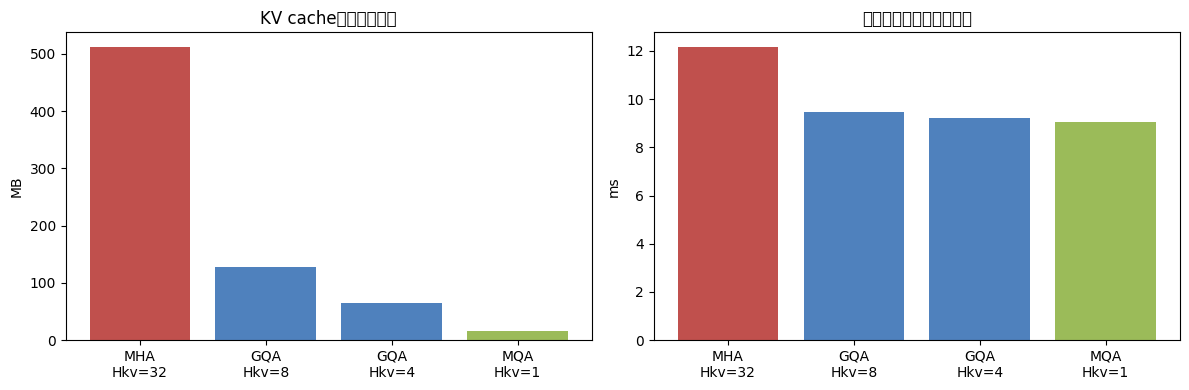

KV cache: MHA 512MB → MQA 16MB（省 32×）；延迟: 12.2ms → 9.1ms（基本持平甚至略降）。


In [9]:
Hq, D, S, B = 32, 128, 4096, 8
hkvs = [32, 8, 4, 1]
kv_mb, lat = [], []
for Hkv in hkvs:
    q, k, v = make_qkv(B, Hq, S, D, kv_heads=Hkv, dtype=torch.float16, seed=0)
    kv_mb.append(2 * B * Hkv * S * D * 2 / 1024**2)
    lat.append(bench_ms(lambda: gqa_attention(q, k, v, causal=True)))
    del q, k, v; torch.cuda.empty_cache()

labels = [("MHA" if h==Hq else "MQA" if h==1 else "GQA") + f"\nHkv={h}" for h in hkvs]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(labels, kv_mb, color=["#c0504d","#4f81bd","#4f81bd","#9bbb59"])
ax1.set(title="KV cache（越小越好）", ylabel="MB")
ax2.bar(labels, lat, color=["#c0504d","#4f81bd","#4f81bd","#9bbb59"])
ax2.set(title="注意力延迟（几乎不变）", ylabel="ms")
plt.tight_layout(); plt.show()
print(f"KV cache: MHA {kv_mb[0]:.0f}MB → MQA {kv_mb[-1]:.0f}MB（省 {kv_mb[0]/kv_mb[-1]:.0f}×）；"
      f"延迟: {lat[0]:.1f}ms → {lat[-1]:.1f}ms（基本持平甚至略降）。")


## 收尾

- 推理的显存杀手是 **KV cache**，它正比于 K/V 头的数量；
- **GQA / MQA** 让多个 query 头共享 K/V 头，把缓存成倍砍小，而模型质量、注意力延迟几乎不变；
- 实现的灵魂只是一句 **`cur_kv_head = cur_head // kv_group_num`**——同一份 kernel 通吃 MHA/GQA/MQA；
- 真省显存的前提是**索引映射**（KV 只存 Hkv 份），而非物理复制；
- 顺带见识了真实推理的 **varlen** 输入格式。

**下一站** → `04-sliding-window`：让每个 token 只看最近的一段窗口。有意思的是——
本章这个 kernel **已经自带**滑动窗口能力，下一章我们就把它点亮。
